In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data=pd.read_excel('https://robertohincapie.com/data/reporte2.xlsx')
data['Créditos Aprobados Progr. Actual']=data['Créditos Aprobados Progr. Actual'].astype(int)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9206 entries, 0 to 9205
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Escuela                            9206 non-null   object 
 1   Edad                               9206 non-null   int64  
 2   Género                             9206 non-null   object 
 3   Créditos Cancelados Progr. Actual  9206 non-null   int64  
 4   Créditos Aprobados Progr. Actual   9206 non-null   int64  
 5   Promedio notas                     9206 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 431.7+ KB


In [ ]:
#Pregunta No. 1: Porcentaje de mujeres que hay en cada escuela
gr=data.groupby(['Escuela','Género']).agg({'Género':'count'})
gr_total=data.groupby(['Escuela']).agg({'Género':'count'})
gr_total.columns=['Total']
print(gr_total)
gr_fem=data[data['Género']=='F'].groupby('Escuela').agg({'Género':'count'})
print(gr_fem)
gr=gr_total.join(gr_fem)
gr['Porcentaje']=gr['Género']/gr['Total']
print(gr)

                                Total
Escuela                              
Arquitectura y Diseño-Med        1584
Ciencias Sociales-Med            1573
Ciencias de la Salud-Med         1320
Derecho Ciencias Políticas-Med    547
Economía,Admon y Negocios-Med     794
Educación y Pedagogía-Med         504
Ingeniería-Med                   2279
Teología Filosofía y Hum-Med      605
                                Género
Escuela                               
Arquitectura y Diseño-Med          998
Ciencias Sociales-Med             1172
Ciencias de la Salud-Med          1040
Derecho Ciencias Políticas-Med     317
Economía,Admon y Negocios-Med      337
Educación y Pedagogía-Med          302
Ingeniería-Med                     703
Teología Filosofía y Hum-Med       239
                                Total  Género  Porcentaje
Escuela                                                  
Arquitectura y Diseño-Med        1584     998    0.630051
Ciencias Sociales-Med            1573    1172    0.74507

In [ ]:
#Pregunta 2. A qué genero le va mejor como estudiante?
data.groupby(['Escuela','Género']).agg({'Promedio notas':'mean'})

Promedio notas
Escuela                        Género                
Arquitectura y Diseño-Med      F             4.100483
                               M             3.859568
Ciencias Sociales-Med          F             4.278351
                               M             4.110611
                               N             4.171187
Ciencias de la Salud-Med       F             3.927155
                               M             3.890762
Derecho Ciencias Políticas-Med F             4.101028
                               M             3.899575
                               N             3.160000
Economía,Admon y Negocios-Med  F             3.962994
                               M             3.830638
                               N             3.870000
Educación y Pedagogía-Med      F             4.315735
                               M             4.133995
Ingeniería-Med                 F             3.979912
                               M             3.828026
                               N             4.142500
Teología Filosofía y Hum-Med   F             4.380925
                               M             4.179922

Miremos algunas gráficas que pueden mostrar relaciones interesantes entre las diferentes variables. Entre ellas contamos con las curvas BoxPlot, que relacionan las medidas de tendencia central con las medidas de dispersión.

También podemos observar histogramas de las variables, así como curvas de dispersión donde se muestre una variable respecto a otra.

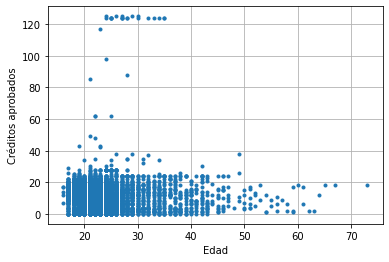

In [ ]:
plt.plot(data['Edad'], data['Créditos Aprobados Progr. Actual'],'.')
plt.xlabel('Edad')
plt.ylabel('Créditos aprobados')
plt.grid()

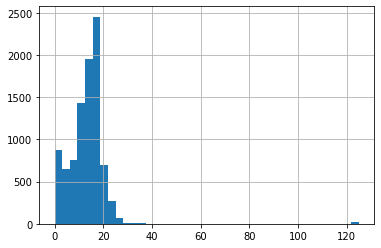

In [ ]:
data['Créditos Aprobados Progr. Actual'].hist(bins=40)

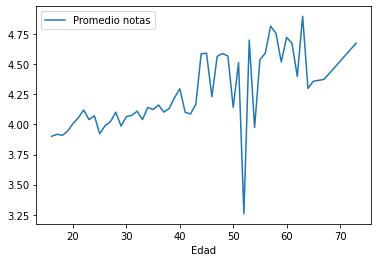

In [ ]:
#Pregunta No. 3, depende el desempeño académico de la edad de los estudiantes?
data.groupby(['Edad']).agg({'Promedio notas':'mean'}).plot()

<Figure size 432x288 with 0 Axes>

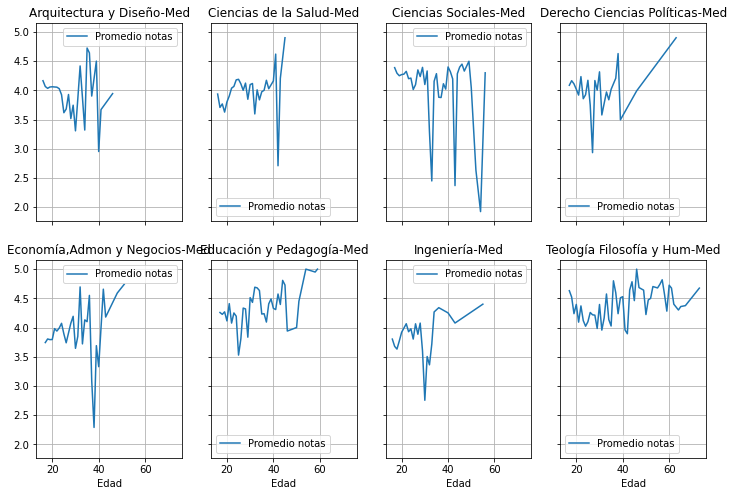

In [ ]:
plt.figure()
fig, ax = plt.subplots(figsize=(12,8), nrows=2, ncols=4, sharex=True, sharey=True)
indf=0
indc=0
for esc in data['Escuela'].unique():
  data[data['Escuela']==esc].groupby(['Edad']).agg({'Promedio notas':'mean'}).plot(ax=ax[indf, indc])
  ax[indf, indc].title.set_text(esc)
  ax[indf, indc].grid()
  indc+=1
  if(indc>3):
    indc=0
    indf+=1